In [70]:
import numpy as np
import pandas as pd
import torch
from torchinfo import summary

from matplotlib import pyplot as plt
import seaborn as sns

from func.load_mnist import load_mnist
from Model_QuantizedAE import QuantizedAE

In [71]:
# Load model, weigts and dataset

model = QuantizedAE()
state_dict = torch.load("data/model_weights/QuantizedAE.pnn", map_location=torch.device("cpu"))
model.load_state_dict(state_dict)

# Now we get the individual parts of the model
preprocess = model.preprocess
bcnn = model.features
bcnn

Sequential(
  (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (1): BinaryConv2d()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): QuantizeBinary()
  (4): BinaryConv2d()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): QuantizeBinary()
  (7): BinaryConv2d()
  (8): QuantizeBinary()
)

In [72]:
summary(bcnn, (1,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 64, 1, 1]             --
├─MaxPool2d: 1-1                         [1, 1, 14, 14]            --
├─BinaryConv2d: 1-2                      [1, 8, 12, 12]            72
├─MaxPool2d: 1-3                         [1, 8, 6, 6]              --
├─QuantizeBinary: 1-4                    [1, 8, 6, 6]              --
├─BinaryConv2d: 1-5                      [1, 16, 4, 4]             1,152
├─MaxPool2d: 1-6                         [1, 16, 2, 2]             --
├─QuantizeBinary: 1-7                    [1, 16, 2, 2]             --
├─BinaryConv2d: 1-8                      [1, 64, 1, 1]             4,096
├─QuantizeBinary: 1-9                    [1, 64, 1, 1]             --
Total params: 5,320
Trainable params: 5,320
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.28
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.02
Estimated Total Size (MB): 0

In [101]:
# Now we try to recreate our own layers
# Note the data is the following: C, H, W
def maxpool_k2_s2(data):
    C, H, W = data.shape
    s = data.strides  # (s0, s1, s2)
    windows = np.lib.stride_tricks.as_strided(
        data,
        shape=(C, H//2, W//2, 2, 2),
        strides=(s[0], s[1]*2, s[2]*2, s[1], s[2])
    )
    return windows.max(axis=(-2, -1))


# The data is of shape CINxHxW and the weights are of shape COUTxCINxHxW
def conv2d(data: np.ndarray, weights: np.ndarray) -> np.ndarray:
  assert weights.shape[-1] == 3 and weights.shape[-2] == 3, \
      f"kernels must be 3x3, got {weights.shape[-1]}x{weights.shape[-2]}"
  
  KW, KH = 3, 3
  C, H, W = data.shape
  N_CHNLS = weights.shape[0]
  
  out_H = H - 2  # no padding, stride 1: (H - KH) + 1
  out_W = W - 2

  # build sliding windows over spatial dims: (out_H, out_W, C, KH, KW)
  s = data.strides
  windows = np.lib.stride_tricks.as_strided(
      data,
      shape=(out_H, out_W, C, KH, KW),
      strides=(s[1], s[2], s[0], s[1], s[2])
  )

  # flatten each window patch into a vector: (out_H, out_W, C*KH*KW)
  windows_flat = windows.reshape(out_H, out_W, -1)

  # flatten each kernel into a vector too: (N_CHNLS, C*KH*KW)
  weights_flat = weights.reshape(N_CHNLS, -1)

  # dot product: every position (h,w) against every kernel n
  # (out_H, out_W, C*KH*KW) @ (C*KH*KW, N_CHNLS) -> (out_H, out_W, N_CHNLS)
  out = windows_flat @ weights_flat.T

  # move channel dim to front to match (N_CHNLS, out_H, out_W)
  return out.transpose(2, 0, 1)




def conv2d_last(data: np.ndarray, weights: np.ndarray) -> np.ndarray:
    assert data.shape == (16, 2, 2), \
        f"expected data shape (16, 2, 2), got {data.shape}"
    assert weights.shape == (64, 16, 2, 2), \
        f"expected weights shape (64, 16, 2, 2), got {weights.shape}"

    KH, KW = 2, 2
    C, H, W = data.shape
    N_CHNLS = weights.shape[0]
    out_H = H - KH + 1  # = 1
    out_W = W - KW + 1  # = 1

    s = data.strides
    windows = np.lib.stride_tricks.as_strided(
        data,
        shape=(out_H, out_W, C, KH, KW),
        strides=(s[1], s[2], s[0], s[1], s[2])
    )

    windows_flat = windows.reshape(out_H, out_W, -1)   # (1, 1, 16*2*2=64)
    weights_flat = weights.reshape(N_CHNLS, -1)        # (64, 64)

    out = windows_flat @ weights_flat.T                # (1, 1, 64)
    return out.transpose(2, 0, 1)                      # (64, 1, 1)

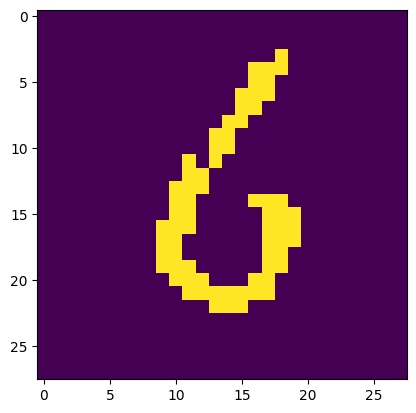

torch.Size([1, 28, 28])

In [ ]:
# Now we load the data from mnist and let it run
_, validate_dl = load_mnist()
img, label = validate_dl.dataset.__getitem__(50)
img_preprocessed = preprocess(img)

img_np = img_preprocessed.detach().numpy()
plt.imshow(img_np.squeeze())
plt.show()

In [122]:
def get_conv_w(cnl):
  w = cnl.get_parameter("weights").detach().numpy()
  return np.sign(w)

def run_model(img_np):
  # Now I want to recreate the encoder pass
  l1 = maxpool_k2_s2(img_np)
  l2 = conv2d(l1, get_conv_w(bcnn[1]))
  l3 = maxpool_k2_s2(l2)
  l4 = np.sign(l3)
  l5 = conv2d(l4, get_conv_w(bcnn[4]))
  l6 = maxpool_k2_s2(l5)
  l7 = np.sign(l6)
  l8 = conv2d_last(l7, get_conv_w(bcnn[7]))
  l9 = np.sign(l8)
  embedding = l9.flatten().astype(np.int8)
  return embedding

In [123]:
get_conv_w(bcnn[7]).shape

(64, 16, 2, 2)

In [137]:
import xgboost as xgb

booster = xgb.Booster()
booster.load_model("data/model_weights/xgb_decision_tree.json")

def predict(embedding: np.ndarray) -> int:
    # embedding must be 2D for DMatrix: (1, 64)
    if embedding.ndim == 1:
        embedding = embedding.reshape(1, -1)

    # wrap in DataFrame to preserve feature names the booster was trained on
    import pandas as pd
    feature_cols = [f"e{i}" for i in range(embedding.shape[1])]
    df = pd.DataFrame(embedding, columns=feature_cols).astype("category")

    dmatrix = xgb.DMatrix(df, enable_categorical=True)
    pred = booster.predict(dmatrix).astype(int)
    return pred[0]

In [140]:
# Now we run throught the whole validation dataset to check
pass_count = 0
correct_count = 0

for img, label in iter(validate_dl.dataset):
  # preprocess image
  img_preprocessed = preprocess(img)
  embedding = run_model(img_preprocessed.detach().numpy())
  pred_label = predict(embedding)
  correct_count += pred_label==label
  # passcount
  if pass_count%100==0:
    print(pass_count)
  pass_count += 1

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900


In [142]:
correct_count / len(validate_dl.dataset)

np.float64(0.7178)